<a href="https://colab.research.google.com/github/peterdomjan-maker/Biomed2026/blob/main/S5_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIOMED-DATA 26 · Session 5
## Neural networks I: the multilayer perceptron
**Train an MLP on the diagnosis, see why scaling matters, and compare it honestly to boosting**

> **STUDENT — fill in the blanks**
>
> Dataset: UCI Heart Disease (`ucimlrepo`, id=45). Runs in Colab: `Runtime → Run all`.
> Semmelweis University · Luca Szegletes (BME)
---

In [1]:
!pip -q install ucimlrepo scikit-learn plotly pandas matplotlib

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

## 0. Load, split, preprocess

In [3]:
heart = fetch_ucirepo(id=45)
X = heart.data.features.copy(); y = (heart.data.targets["num"] > 0).astype(int)
numeric=["age","trestbps","chol","thalach","oldpeak"]
categorical=["sex","cp","fbs","restecg","exang","slope","ca","thal"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pre = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), numeric),
    ("cat", Pipeline([("i",SimpleImputer(strategy="most_frequent")),("o",OneHotEncoder(handle_unknown="ignore"))]), categorical),
])
def auc(m): return roc_auc_score(y_te, m.predict_proba(X_te)[:,1])

## 1. A small MLP
Two hidden layers, ReLU, early stopping. The network is a stack of the neurons from the lecture.

In [4]:
# TODO: two hidden layers (32, 16), relu, early_stopping=True

mlp = Pipeline([
    ("pre", pre),
    ("m", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        alpha=1e-3,
        max_iter=500,
        early_stopping=True,
        random_state=0
    ))
]).fit(X_tr, y_tr)

print("MLP test AUC:", round(auc(mlp), 3))

MLP test AUC: 0.894


## 2. Why scaling matters
Fit the same MLP on raw (unscaled) features and compare. Neural networks are the least forgiving about scale.

In [5]:
from sklearn.impute import SimpleImputer as Imp
raw = Pipeline([("i", Imp(strategy="median")),
                ("m", MLPClassifier(hidden_layer_sizes=(32,16), max_iter=500, early_stopping=True, random_state=0))])
raw.fit(X_tr[numeric], y_tr)
print("Unscaled numeric-only MLP AUC:", round(roc_auc_score(y_te, raw.predict_proba(X_te[numeric])[:,1]),3))
print("Scaled full MLP AUC:          ", round(auc(mlp),3))

Unscaled numeric-only MLP AUC: 0.748
Scaled full MLP AUC:           0.894


## 3. The loss curve
Watch training loss fall. If it plateaus high, raise the learning rate; if it spikes, lower it.

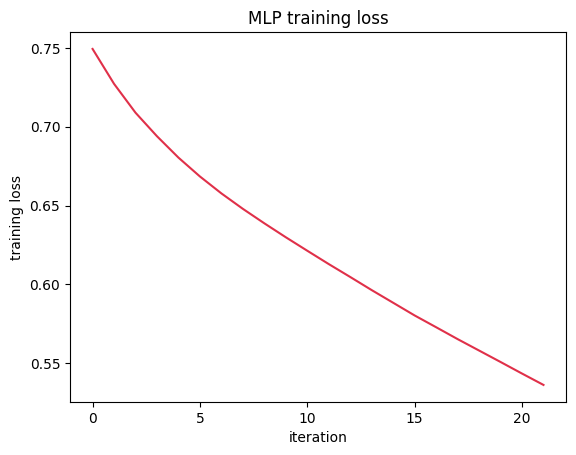

In [6]:
net = mlp.named_steps["m"]

# TODO: plot net.loss_curve_
plt.plot(net.loss_curve_, color="#e03049")
plt.xlabel("iteration")
plt.ylabel("training loss")
plt.title("MLP training loss")
plt.show()

## 4. Compare to logistic and boosting
The honest question: does the MLP beat the simpler and the stronger model on this small table?

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(32, 16),
        alpha=1e-3,
        max_iter=500,
        early_stopping=True,
        random_state=0
    ),
    "Gradient boosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=400,
        early_stopping=True,
        random_state=0
    )
}

for n, m in models.items():
    cv = cross_val_score(
        Pipeline([("pre", pre), ("m", m)]),
        X_tr,
        y_tr,
        cv=5,
        scoring="roc_auc"
    ).mean()

    print(f"{n:18s} CV AUC = {cv:.3f}")

Logistic           CV AUC = 0.894
MLP                CV AUC = 0.775
Gradient boosting  CV AUC = 0.885


## 5. Regularization: the alpha knob
Larger alpha (weight decay) simplifies the network. Sweep it and watch cross-validated AUC.

In [8]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
for a in alphas:
    m = Pipeline([("pre",pre),("m",MLPClassifier(hidden_layer_sizes=(32,16), alpha=a, max_iter=500,
                  early_stopping=True, random_state=0))])
    cv = cross_val_score(m, X_tr, y_tr, cv=5, scoring="roc_auc").mean()
    print(f"alpha={a:<7} CV AUC = {cv:.3f}")

alpha=0.0001  CV AUC = 0.775
alpha=0.001   CV AUC = 0.775
alpha=0.01    CV AUC = 0.775
alpha=0.1     CV AUC = 0.775
alpha=1.0     CV AUC = 0.774


## Questions to think about
1. How much did removing scaling hurt the MLP? Why are neural networks so sensitive to it?
2. Did the MLP beat boosting here? On a table this size, which would you ship, and why?
3. What did the alpha sweep suggest — was more regularization better or worse?

*Next session: attention and the TabTransformer.*